##**Importing Libraries and Dataset**

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

In [2]:
store = pd.read_csv('Global_Superstore2 - Global_Superstore2.csv')
store.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,32298,CA-2012-124891,31-07-2012,31-07-2012,Same Day,RH-19495,Rick Hansen,Consumer,New York City,New York,...,TEC-AC-10003033,Technology,Accessories,Plantronics CS510 - Over-the-Head monaural Wir...,2309.650,7,0.0,762.1845,933.57,Critical
1,26341,IN-2013-77878,05-02-2013,07-02-2013,Second Class,JR-16210,Justin Ritter,Corporate,Wollongong,New South Wales,...,FUR-CH-10003950,Furniture,Chairs,"Novimex Executive Leather Armchair, Black",3709.395,9,0.1,-288.7650,923.63,Critical
2,25330,IN-2013-71249,17-10-2013,18-10-2013,First Class,CR-12730,Craig Reiter,Consumer,Brisbane,Queensland,...,TEC-PH-10004664,Technology,Phones,"Nokia Smart Phone, with Caller ID",5175.171,9,0.1,919.9710,915.49,Medium


##**Exploring and Cleaning Dataset**

In [3]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     9994 non-null   float64
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [4]:
copy = store.copy()

In [5]:
copy.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [6]:
copy['Postal Code'].fillna('N/A', inplace=True)

/tmp/ipykernel_25687/2905172417.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  copy['Postal Code'].fillna('N/A', inplace=True)
/tmp/ipykernel_25687/2905172417.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'N/A' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  copy['Postal Code'].fillna('N/A', inplace=True)


In [7]:
copy.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [8]:
copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Postal Code     51290 non-null  object 
 12  Market          51290 non-null  object 
 13  Region          51290 non-null  object 
 14  Product ID      51290 non-null  object 
 15  Category        51290 non-null  object 
 16  Sub-Category    51290 non-null  object 
 17  Product Name    51290 non-null 

In [9]:
copy['Order Date'] = pd.to_datetime(copy['Order Date'], errors='coerce', format='%d-%m-%Y')
copy['Ship Date'] = pd.to_datetime(copy['Ship Date'], errors='coerce', format='%d-%m-%Y')

In [10]:
copy['Year'] = copy['Order Date'].dt.year
copy['Month'] = copy['Order Date'].dt.month
copy['Day'] = copy['Order Date'].dt.day
copy['Quarter'] = copy['Order Date'].dt.to_period('Q')

In [11]:
copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 28 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51290 non-null  int64         
 1   Order ID        51290 non-null  object        
 2   Order Date      51290 non-null  datetime64[ns]
 3   Ship Date       51290 non-null  datetime64[ns]
 4   Ship Mode       51290 non-null  object        
 5   Customer ID     51290 non-null  object        
 6   Customer Name   51290 non-null  object        
 7   Segment         51290 non-null  object        
 8   City            51290 non-null  object        
 9   State           51290 non-null  object        
 10  Country         51290 non-null  object        
 11  Postal Code     51290 non-null  object        
 12  Market          51290 non-null  object        
 13  Region          51290 non-null  object        
 14  Product ID      51290 non-null  object        
 15  Ca

In [12]:
copy.describe()

,Row ID,Order Date,Ship Date,Sales,Quantity,Discount,Profit,Shipping Cost,Year,Month,Day
count,51290.00000,51290,51290,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000,51290.000000
mean,25645.50000,2013-05-11 21:26:49.155781120,2013-05-15 20:42:42.745174528,246.490581,3.476545,0.142908,28.610982,26.375915,2012.777208,7.522636,15.782960
min,1.00000,2011-01-01 00:00:00,2011-01-03 00:00:00,0.444000,1.000000,0.000000,-6599.978000,0.000000,2011.000000,1.000000,1.000000
25%,12823.25000,2012-06-19 00:00:00,2012-06-23 00:00:00,30.758625,2.000000,0.000000,0.000000,2.610000,2012.000000,5.000000,8.000000
50%,25645.50000,2013-07-08 00:00:00,2013-07-12 00:00:00,85.053000,3.000000,0.000000,9.240000,7.790000,2013.000000,8.000000,16.000000
75%,38467.75000,2014-05-22 00:00:00,2014-05-26 00:00:00,251.053200,5.000000,0.200000,36.810000,24.450000,2014.000000,10.000000,23.000000
max,51290.00000,2014-12-31 00:00:00,2015-01-07 00:00:00,22638.480000,14.000000,0.850000,8399.976000,933.570000,2014.000000,12.000000,31.000000
std,14806.29199,NaN,NaN,487.565361,2.278766,0.212280,174.340972,57.296804,1.098931,3.300056,8.742164


In [13]:
copy.describe(include='object')

,Order ID,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,Market,Region,Product ID,Category,Sub-Category,Product Name,Order Priority
count,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290,51290
unique,25035,4,1590,795,3,3636,1094,147,632,7,13,10292,3,17,3788,4
top,CA-2014-100111,Standard Class,PO-18850,Muhammed Yedwab,Consumer,New York City,California,United States,N/A,APAC,Central,OFF-AR-10003651,Office Supplies,Binders,Staples,Medium
freq,14,30775,97,108,26518,915,2001,9994,41296,11002,11117,35,31273,6152,227,29433


##**EDA**

### EDA Insights

In [14]:
outlier1=px.box(copy,y='Sales')
outlier1.show()

In [15]:
outlier2 = px.box(copy, y='Profit')
outlier2.show()

In [16]:
outlier3 = px.box(copy, y='Quantity')
outlier3.show()

In [17]:
outlier4 = px.box(copy, y='Discount')
outlier4.show()

In [18]:
outlier5= px.box(copy,y='Shipping Cost')
outlier5.show()

###Handling Outliers

In [19]:
print(len(copy[copy['Sales'] >= 4000]))
print(len(copy[copy['Profit'] >= 1200]))
print(len(copy[(copy['Discount'] >= 0.5)]))
print(len(copy[(copy['Quantity'] >= 9)]))
print(len(copy[(copy['Shipping Cost'] >= 560)]))

90
89
5805
1864
86


In [20]:
copy=copy[copy['Profit'] <= 1200]

In [21]:
copy=copy[copy['Sales'] <= 4000]
copy=copy[copy['Discount'] <= 0.5]
copy=copy[copy['Quantity'] <= 9]
copy=copy[copy['Shipping Cost'] <= 560]

##**Insights**

###Best Selling Category

In [22]:
best_selling_category = px.bar(copy.groupby('Category')['Sales'].sum().sort_values(ascending=False).reset_index(), x='Category', y='Sales')
best_selling_category.update_yaxes(range=[0,5000000])
best_selling_category.update_xaxes(range=[-0.5,2.5])
best_selling_category.update_layout(title='Best Selling Category')
best_selling_category.show()

###Best Selling Sub-Category

In [23]:
best_selling_sub_category = px.bar(copy.groupby('Sub-Category')['Sales'].sum().sort_values(ascending=False).reset_index(), x='Sub-Category', y='Sales')
best_selling_sub_category.update_yaxes(range=[0,1650000])
best_selling_sub_category.update_layout(title='Best Selling Sub-Category')
best_selling_sub_category.show()

###Best Selling Market

In [24]:
best_selling_market_pie = px.pie(copy.groupby('Market')['Sales'].sum().sort_values(ascending=False).reset_index(), names='Market', values='Sales')
best_selling_market_pie.update_layout(title='Best Selling Market')
best_selling_market_pie.show()

###Best Selling Region

In [25]:
best_selling_region = px.bar(copy.groupby('Region')['Sales'].sum().sort_values(ascending=False).reset_index(), x='Region', y='Sales')
best_selling_region.update_layout(title='Best Selling Region')
best_selling_region.show()

###Best Selling Country

In [26]:
best_selling_country_tree = px.treemap(copy.groupby('Country')['Sales'].sum().sort_values(ascending=False).reset_index(), path=['Country'], values='Sales')
best_selling_country_tree.update_layout(title='Best Selling Country')
best_selling_country_tree.show()

###Best Selling Segment

In [27]:
best_selling_segment_pie = px.pie(copy.groupby('Segment')['Sales'].sum().sort_values(ascending=False).reset_index(), names='Segment', values='Sales')
best_selling_segment_pie.update_layout(title='Best Selling Segment')
best_selling_segment_pie.show()

###Top 5 Product

In [28]:
best_selling_product = px.bar(copy.groupby('Product Name')['Sales'].sum().sort_values(ascending=False).reset_index().head(5), x='Product Name', y='Sales')
best_selling_product.update_layout(title='Top 5 Products')
best_selling_product.show()

### Most Selected Shipment Mode

In [29]:
most_selected_ship_mode = px.pie(copy['Ship Mode'].value_counts().reset_index(), names='Ship Mode', values='count', title='Most Selected Shipment Mode')
most_selected_ship_mode.update_layout(title='Most Selected Shipment Mode')
most_selected_ship_mode.show()

### Sales by Each Quarter

In [30]:
quarterly_sales = copy.groupby('Quarter')['Sales'].sum().reset_index()
quarterly_sales['Quarter'] = quarterly_sales['Quarter'].astype(str)
sales_by_quarter = px.line(quarterly_sales, x='Quarter', y='Sales')
sales_by_quarter.update_yaxes(range=[0,1600000])
sales_by_quarter.update_xaxes(range=[-0.2,15.5], tickangle=-45)
sales_by_quarter.update_layout(title='Sales by Each Quarter')
sales_by_quarter.show()

###Sales by Each Year

In [31]:
sales_by_year = px.line(copy.groupby('Year')['Sales'].sum().reset_index(), x='Year', y='Sales')
sales_by_year.update_xaxes(tickmode='linear', dtick=1)
sales_by_year.update_yaxes(range=[1800000,4600000])
sales_by_year.update_layout(title='Sales by Each Year')
sales_by_year.show()

### Top 10 Customers with the most orders

In [32]:
from numpy._core.defchararray import title
customers_most_orders = copy.groupby('Customer Name')['Order ID'].count().sort_values(ascending=False).reset_index().head(10)
most_orders_fig = px.bar(customers_most_orders, x='Customer Name', y='Order ID')
most_orders_fig.update_yaxes(title = 'Number of Orders')
most_orders_fig.update_xaxes(title = 'Customer Name')
most_orders_fig.update_layout(title = 'Top 10 Customers with the most orders')
most_orders_fig.update_yaxes(range=[0,130])
most_orders_fig.show()

### Customers with least orders

In [33]:
customer_least_orders = copy.groupby('Customer Name')['Order ID'].count().sort_values(ascending=True).reset_index().head(5)
least_orders_fig = px.bar(customer_least_orders, x='Customer Name', y='Order ID')
least_orders_fig.update_yaxes(title = 'Number of Orders')
least_orders_fig.update_xaxes(title = 'Customer Name')
least_orders_fig.update_layout(title = 'Customers with least orders')
least_orders_fig.show()

###Revenue: Discount VS No Discount

In [34]:
revenue = copy.groupby(copy['Discount'] > 0)['Sales'].sum()
revenue_fig = px.bar(revenue, x=revenue.index, y=revenue.values)
revenue_fig.update_xaxes(title = 'Discount')
revenue_fig.update_yaxes(title = 'Revenue')
revenue_fig.update_layout(title = 'Revenue: Discount VS No Discount')
revenue_fig.show()

  ## **Machine Learning**

### Profit Prediction


#### Feature Engineering

In [35]:
categorical_columns = copy.select_dtypes(include=['object', 'category']).columns
categorical_columns
for i in categorical_columns:
    print(copy[i].value_counts())
    print('\n')

Order ID
IN-2013-42311     13
TO-2014-9950      13
CA-2014-100111    13
MX-2014-166541    13
MX-2013-142678    12
                  ..
IN-2014-72327      1
IN-2014-57662      1
MX-2012-134460     1
MX-2014-136623     1
IN-2012-60693      1
Name: count, Length: 23084, dtype: int64


Ship Mode
Standard Class    27772
Second Class       9267
First Class        6700
Same Day           2409
Name: count, dtype: int64


Customer ID
PO-18850    91
JG-15805    87
BE-11335    86
SW-20755    86
MY-18295    81
            ..
FH-4350      1
AD-180       1
MP-7470      1
SC-10800     1
VP-11730     1
Name: count, Length: 1580, dtype: int64


Customer Name
Steven Ward            101
Muhammed Yedwab         96
Patrick O'Brill         95
Art Ferguson            94
Harry Greene            93
                      ... 
David Bremer            30
Emily Burns             29
Catherine Glotzbach     26
Michael Oakman          26
Nicole Brennan          25
Name: count, Length: 795, dtype: int64


Segment
Cons

In [36]:
copy['Order Value'] = copy['Sales'] + copy['Shipping Cost']
copy['shipping_per_item'] = copy['Shipping Cost'] / copy['Quantity']
copy['profit_margin'] = (copy['Profit'] / copy['Sales'])*100

In [37]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
numeric_copy = copy.copy()

# Ensure 'Postal Code' column is uniformly string type before encoding
# This addresses the TypeError: "<' not supported between instances of 'str' and 'float'"
if 'Postal Code' in categorical_columns:
    numeric_copy['Postal Code'] = numeric_copy['Postal Code'].astype(str)

for column in categorical_columns:
    numeric_copy[column] = label_encoder.fit_transform(numeric_copy[column])

In [38]:
for i in numeric_copy:
    print(numeric_copy[i].value_counts())
    print('\n')

Row ID
6147     1
45616    1
25026    1
27962    1
34657    1
        ..
26731    1
46366    1
19195    1
38411    1
29600    1
Name: count, Length: 46148, dtype: int64


Order ID
12296    13
20919    13
3124     13
19814    13
18228    12
         ..
13907     1
13660     1
17156     1
19294     1
11591     1
Name: count, Length: 23084, dtype: int64


Order Date
2014-09-03    119
2014-06-18    113
2014-11-18    111
2014-11-20    111
2014-11-13    109
             ... 
2012-05-20      1
2013-11-10      1
2012-10-07      1
2014-01-19      1
2013-07-21      1
Name: count, Length: 1426, dtype: int64


Ship Date
2014-11-22    118
2014-09-07    108
2014-11-17     98
2014-11-29     96
2014-11-16     91
             ... 
2011-01-06      2
2011-01-03      2
2012-02-15      2
2012-02-27      2
2011-01-05      2
Name: count, Length: 1464, dtype: int64


Ship Mode
3    27772
2     9267
0     6700
1     2409
Name: count, dtype: int64


Customer ID
1198    91
729     87
150     86
1450    86
1091  

In [39]:
numeric_copy.head(3)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Profit,Shipping Cost,Order Priority,Year,Month,Day,Quarter,Order Value,shipping_per_item,profit_margin
86,45616,16004,2013-11-23,2013-11-23,1,19,16,2,559,316,...,113.280,556.45,3,2013,11,23,2013Q4,2822.890,139.112500,4.998147
87,25026,11631,2012-06-13,2012-06-13,1,1298,617,1,2912,613,...,1124.901,555.77,1,2012,6,13,2012Q2,3624.131,61.752222,36.661299
88,27962,12370,2013-10-28,2013-10-31,0,177,83,0,3037,242,...,1192.860,553.31,3,2013,10,28,2013Q4,4281.740,61.478889,31.993627


In [40]:
target_col = 'Profit'

# Select only numeric columns for correlation, excluding datetime and Period types
numeric_cols_for_corr = numeric_copy.select_dtypes(include=['number']).columns
if target_col not in numeric_cols_for_corr:
    print(f"Warning: Target column '{target_col}' not found in numeric columns for correlation.")

numeric_copy = numeric_copy.drop(columns=['Quarter', 'Order Date', 'Ship Date'], errors='ignore').select_dtypes(include=['number'])

corr = numeric_copy.corr()[target_col].sort_values(ascending=False)
print(corr)

Profit               1.000000
Sales                0.531113
Order Value          0.529655
Shipping Cost        0.431343
profit_margin        0.426195
shipping_per_item    0.351838
Quantity             0.141584
Category             0.070243
Product ID           0.041159
Row ID               0.023008
Postal Code          0.018066
City                 0.012275
Product Name         0.010387
Ship Mode            0.008599
State                0.005836
Segment              0.005623
Year                 0.001141
Month                0.000954
Order Priority      -0.000945
Day                 -0.001323
Customer ID         -0.002462
Customer Name       -0.002577
Market              -0.029019
Region              -0.033305
Order ID            -0.038057
Country             -0.051061
Sub-Category        -0.053604
Discount            -0.321227
Name: Profit, dtype: float64


#### Skewness

In [41]:
numeric_copy.skew().sort_values(ascending=False)

,0
shipping_per_item,5.197686
Shipping Cost,4.540018
Sales,3.599021
Order Value,3.565557
Profit,2.043503
Discount,1.433291
Quantity,0.900006
Segment,0.651255
Sub-Category,0.078879
Row ID,0.076130


In [42]:
numeric_copy.columns

Index(['Row ID', 'Order ID', 'Ship Mode', 'Customer ID', 'Customer Name',
       'Segment', 'City', 'State', 'Country', 'Postal Code', 'Market',
       'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name',
       'Sales', 'Quantity', 'Discount', 'Profit', 'Shipping Cost',
       'Order Priority', 'Year', 'Month', 'Day', 'Order Value',
       'shipping_per_item', 'profit_margin'],
      dtype='object')

In [43]:
from scipy.stats import skew
columns_to_transform = ['profit_margin','Discount','Sales','Profit','Order Value','Shipping Cost']

for col in columns_to_transform:

    original = numeric_copy[col]

    # Store skew results
    skew_results = {}

    # 1) Original skew
    skew_results['original'] = abs(skew(original.dropna()))

    # ---------- TRY LOG ----------
    try:
        log_trans = np.log1p(original - original.min() + 1) if original.min() <= 0 else np.log1p(original)
        skew_results['log'] = abs(skew(log_trans.dropna()))
    except:
        skew_results['log'] = np.inf

    # ---------- TRY SQRT ----------
    try:
        sqrt_trans = np.sqrt(original - original.min() + 1) if original.min() < 0 else np.sqrt(original.clip(lower=0))
        skew_results['sqrt'] = abs(skew(sqrt_trans.dropna()))
    except:
        skew_results['sqrt'] = np.inf

    # ---------- TRY BOXCOX ----------
    try:
        boxcox_input = original - original.min() + 1 if original.min() <= 0 else original
        boxcox_trans, _ = stats.boxcox(boxcox_input)
        skew_results['boxcox'] = abs(skew(boxcox_trans))
    except:
        skew_results['boxcox'] = np.inf

    # ---------- CHOOSE BEST ----------
    best_method = min(skew_results, key=skew_results.get)

    print(f"\nColumn: {col}")
    print("Skewness options:", skew_results)
    print(f"➡ Best method = {best_method}")

    # ---------- APPLY BEST TRANSFORMATION ----------
    if best_method == 'log':
        numeric_copy[col] = log_trans
    elif best_method == 'sqrt':
        numeric_copy[col] = sqrt_trans
    elif best_method == 'boxcox':
        numeric_copy[col] = boxcox_trans
    else:
        numeric_copy[col] = original  # keep original

print("\n✓ All transformations applied to numeric_copy on the same columns.")



Column: profit_margin
Skewness options: {'original': np.float64(1.3980532986323524), 'log': np.float64(4.037603486482221), 'sqrt': np.float64(2.2171931544307713), 'boxcox': inf}
➡ Best method = original

Column: Discount
Skewness options: {'original': np.float64(1.4332448131222681), 'log': np.float64(1.3620435758984384), 'sqrt': np.float64(0.8545189197844664), 'boxcox': inf}
➡ Best method = sqrt

Column: Sales
Skewness options: {'original': np.float64(3.59890394787572), 'log': np.float64(0.15419840404678414), 'sqrt': np.float64(1.6750004500593283), 'boxcox': inf}
➡ Best method = log

Column: Profit
Skewness options: {'original': np.float64(2.043436485456478), 'log': np.float64(27.750412643116398), 'sqrt': np.float64(0.45428075879645247), 'boxcox': inf}
➡ Best method = sqrt

Column: Order Value
Skewness options: {'original': np.float64(3.5654406145560564), 'log': np.float64(0.1474895027107574), 'sqrt': np.float64(1.6671721595994442), 'boxcox': inf}
➡ Best method = log

Column: Shipping

In [44]:
numeric_copy.skew().sort_values()

,0
Postal Code,-2.542389
profit_margin,-1.398099
Ship Mode,-1.218598
Order Priority,-0.601609
Profit,-0.454296
Market,-0.452394
Month,-0.366064
Year,-0.350362
City,-0.133538
State,-0.028239


In [45]:
numeric_copy.to_csv('numeric_copy.csv',index=False)

#### Data Splitting

In [46]:
target_col = 'Profit'
corr = numeric_copy.corr()[target_col].sort_values(ascending=False)
print(corr)

Profit               1.000000
profit_margin        0.434170
Sales                0.355649
Order Value          0.354949
Shipping Cost        0.348671
shipping_per_item    0.325138
Quantity             0.127075
Category             0.069106
Product ID           0.041080
Row ID               0.024833
Postal Code          0.017230
City                 0.013102
Product Name         0.011373
Ship Mode            0.010148
Segment              0.005921
State                0.005060
Year                 0.001979
Month                0.000680
Day                 -0.000021
Order Priority      -0.000054
Customer ID         -0.002214
Customer Name       -0.002349
Market              -0.026665
Region              -0.033680
Order ID            -0.037925
Country             -0.049857
Sub-Category        -0.054150
Discount            -0.295528
Name: Profit, dtype: float64


In [47]:
x=numeric_copy[['Sales','Shipping Cost','Discount','profit_margin','Order Value','shipping_per_item']]
y=numeric_copy[['Profit']]

#### Scaling

In [48]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

#### Model Training & Evaluation

In [49]:
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error , accuracy_score , mean_absolute_percentage_error

In [50]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

####Random Forest
---

In [51]:
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=25,random_state=1200  ,max_depth=5)
rf_model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:1389: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



RandomForestRegressor(max_depth=5, n_estimators=25, random_state=1200)

In [52]:
y_pred_rf = rf_model.predict(x_test)
r2_score(y_test , y_pred_rf)


0.9600952244314033

### Order Priority
---

In [53]:
numeric_copy['Order Priority'].value_counts()

,count
Order Priority,
3,26491
1,13935
0,3520
2,2202


#### Data Splitting

In [54]:
target_col = 'Order Priority'
corr = numeric_copy.corr()[target_col].sort_values(ascending=False)
print(corr)

Order Priority       1.000000
Ship Mode            0.403356
State                0.015388
Segment              0.014319
Year                 0.011375
City                 0.011173
Quantity             0.008634
Discount             0.004580
Sub-Category         0.004432
Day                  0.003521
Order ID             0.003135
Sales                0.002673
Country              0.002193
Postal Code          0.001287
Profit              -0.000054
Month               -0.000658
Product Name        -0.001410
Market              -0.002642
Product ID          -0.003106
Region              -0.004866
Row ID              -0.006077
Category            -0.006356
Customer ID         -0.009187
profit_margin       -0.009467
Customer Name       -0.010415
Order Value         -0.025838
shipping_per_item   -0.228556
Shipping Cost       -0.245389
Name: Order Priority, dtype: float64


In [55]:
x=numeric_copy[['Ship Mode','Shipping Cost','shipping_per_item','State']]
y=numeric_copy[['Order Priority']]

####Scaling

In [56]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x = scaler.fit_transform(x)

#### Fix Imbalancing

In [57]:
from imblearn.combine import SMOTEENN
smoteenn = SMOTEENN(sampling_strategy='auto', random_state=42)
x_res, y_res = smoteenn.fit_resample(x, y)

In [58]:
y_res.value_counts()

,count
Order Priority,
0,19524
2,17968
1,7963
3,6085


#### Model Training & Evaluation

In [59]:
from sklearn.metrics import mean_squared_error, r2_score , mean_absolute_error , accuracy_score , mean_absolute_percentage_error
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x_res,y_res,test_size=0.2,random_state=42)

##### KNN

In [60]:
from sklearn.neighbors import KNeighborsClassifier
classifier = KNeighborsClassifier(n_neighbors =2, metric = 'minkowski', p =2)
classifier.fit(x_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning:

A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().



KNeighborsClassifier(n_neighbors=2)

In [61]:
y_pred = classifier.predict(x_test)
accuracy_score(y_test, y_pred)

0.954210322079938

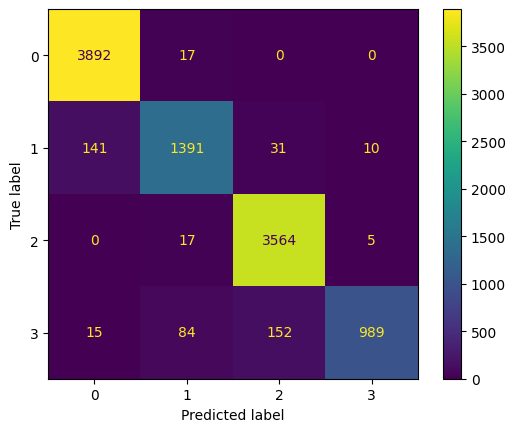

In [62]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm= confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=classifier.classes_)
disp.plot()
plt.show()

###Customer Segmentation

---



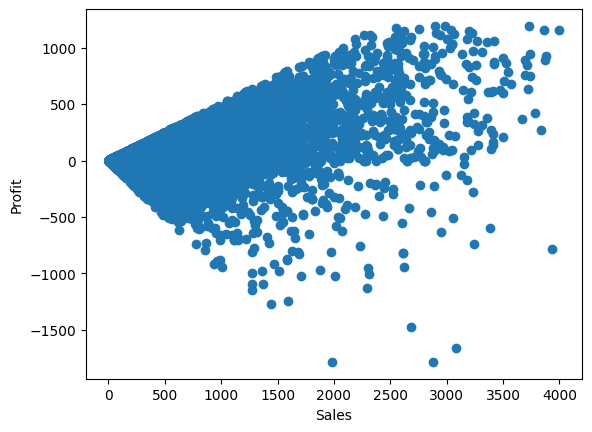

In [63]:
plt.scatter(copy['Sales'],copy['Profit'])
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

####Kmeans Clustering

In [64]:
from sklearn.cluster import KMeans
x = copy[['Sales','Profit']]
kmeans = KMeans(n_clusters=3,random_state=42)
kmeans.fit(x)

KMeans(n_clusters=3, random_state=42)

In [65]:
y_kmeans=kmeans.predict(x)

In [66]:
store_clustered = numeric_copy.copy()
store_clustered['Clusters'] = y_kmeans
store_clustered.head(3)

,Row ID,Order ID,Ship Mode,Customer ID,Customer Name,Segment,City,State,Country,Postal Code,...,Profit,Shipping Cost,Order Priority,Year,Month,Day,Order Value,shipping_per_item,profit_margin,Clusters
86,45616,16004,1,19,16,2,559,316,83,617,...,43.579525,6.325165,3,2013,11,23,7.945871,139.112500,4.998147,2
87,25026,11631,1,1298,617,1,2912,613,6,617,...,53.951793,6.323947,1,2012,6,13,8.195646,61.752222,36.661299,2
88,27962,12370,0,177,83,0,3037,242,10,617,...,54.577972,6.319527,3,2013,10,28,8.362348,61.478889,31.993627,2


In [67]:
store_clustered['Clusters'].value_counts()

,count
Clusters,
0,38832
1,6137
2,1179


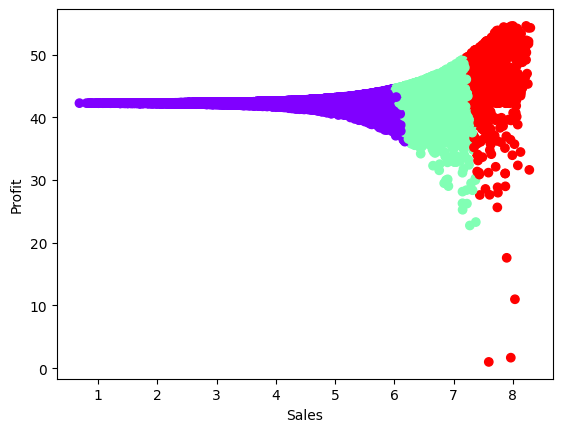

In [68]:
plt.scatter(data=store_clustered,x='Sales',y='Profit',c=kmeans.labels_,cmap='rainbow')
plt.xlabel('Sales')
plt.ylabel('Profit')
plt.show()

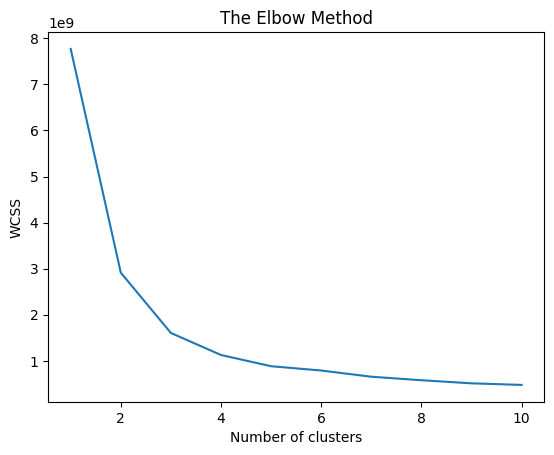

In [69]:
from sklearn.cluster import KMeans
wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters = i, init = 'k-means++', random_state = 42)
    kmeans.fit(x)
    wcss.append(kmeans.inertia_)
plt.plot(range(1, 11), wcss)
plt.title('The Elbow Method')
plt.xlabel('Number of clusters')
plt.ylabel('WCSS')
plt.show()

###Recommender System

---



In [70]:
rec = copy[['Category','Sub-Category','Product Name']]

In [71]:
rec.head(2)

,Category,Sub-Category,Product Name
86,Office Supplies,Appliances,"Hoover Stove, White"
87,Technology,Copiers,"Brother Wireless Fax, Laser"


In [72]:
rec['text'] = rec['Category'] + rec['Sub-Category'] + rec['Product Name']

/tmp/ipykernel_25687/697850756.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [73]:
rec.head()

,Category,Sub-Category,Product Name,text
86,Office Supplies,Appliances,"Hoover Stove, White","Office SuppliesAppliancesHoover Stove, White"
87,Technology,Copiers,"Brother Wireless Fax, Laser","TechnologyCopiersBrother Wireless Fax, Laser"
88,Furniture,Bookcases,"Ikea Classic Bookcase, Mobile","FurnitureBookcasesIkea Classic Bookcase, Mobile"
89,Technology,Copiers,"Canon Copy Machine, Color","TechnologyCopiersCanon Copy Machine, Color"
90,Technology,Phones,"Nokia Smart Phone, with Caller ID","TechnologyPhonesNokia Smart Phone, with Caller ID"


In [74]:
rec.isna().sum()

,0
Category,0
Sub-Category,0
Product Name,0
text,0


In [75]:
rec.duplicated().sum()

np.int64(42379)

In [76]:
rec = rec.drop_duplicates(subset=["text"])

In [77]:
rec.describe(include='object')

,Category,Sub-Category,Product Name,text
count,3769,3769,3769,3769
unique,3,17,3760,3769
top,Office Supplies,Paper,Staples,Office SuppliesAppliancesHolmes Visible Mist U...
freq,2075,393,10,1


In [78]:
import re
from sklearn.feature_extraction.text import CountVectorizer
from nltk.stem import SnowballStemmer
cv = CountVectorizer()
stemmer = SnowballStemmer("english")

In [79]:
def clean(text):
    text = str(text).lower()

    # keep only English letters and spaces
    text = re.sub(r'[^a-z ]+', '', text).strip()

    filtered_words = []
    for word in text.split():
        filtered_words.append(stemmer.stem(word))

    return ' '.join(filtered_words)


rec['clean_text'] = rec.text.apply(clean)

In [80]:
rec['clean_text']

,clean_text
86,offic suppliesapplianceshoov stove white
87,technologycopiersbroth wireless fax laser
88,furniturebookcasesikea classic bookcas mobil
89,technologycopierscanon copi machin color
90,technologyphonesnokia smart phone with caller id
...,...
50485,technologyaccessoriessandisk cruzer gb usb fla...
50528,offic suppliessupplieslett slitter
50793,offic suppliesartsanford uniblaz view highligh...
50833,offic suppliessupplieskleencut forg offic shea...


In [81]:
x = cv.fit_transform(rec.clean_text).toarray()
from sklearn.neighbors import NearestNeighbors
n=5
nbrs = NearestNeighbors(n_neighbors=n+1)
nbrs.fit(x)
distances , indices = nbrs.kneighbors(x)

In [82]:
final_rec = pd.DataFrame(indices,columns=['text','rec1','rec2','rec3','rec4','rec5'])
final_rec.head()

,text,rec1,rec2,rec3,rec4,rec5
0,0,23,1312,317,280,199
1,1,357,330,75,165,120
2,2,445,245,305,114,145
3,3,33,440,485,230,233
4,4,20,266,419,111,84


In [83]:
def replace_i_text(i):
    return rec.iloc[i].text

In [84]:
final_rec = final_rec.applymap(replace_i_text)
final_rec.head()

/tmp/ipykernel_25687/940747044.py:1: FutureWarning:

DataFrame.applymap has been deprecated. Use DataFrame.map instead.



,text,rec1,rec2,rec3,rec4,rec5
0,"Office SuppliesAppliancesHoover Stove, White","Office SuppliesAppliancesHoover Refrigerator, ...","Office SuppliesAppliancesHoover Toaster, White","Office SuppliesAppliancesCuisinart Stove, White","Office SuppliesAppliancesHoover Stove, Silver","Office SuppliesAppliancesHoover Stove, Red"
1,"TechnologyCopiersBrother Wireless Fax, Laser","TechnologyCopiersBrother Wireless Fax, High-Speed","TechnologyCopiersCanon Wireless Fax, Laser","TechnologyCopiersBrother Wireless Fax, Color","TechnologyCopiersBrother Wireless Fax, Digital","TechnologyCopiersHP Wireless Fax, Laser"
2,"FurnitureBookcasesIkea Classic Bookcase, Mobile","FurnitureBookcasesDania Classic Bookcase, Mobile","FurnitureBookcasesSauder Classic Bookcase, Mobile","FurnitureBookcasesBush Classic Bookcase, Mobile","FurnitureBookcasesIkea Classic Bookcase, Metal","FurnitureBookcasesIkea Classic Bookcase, Pine"
3,"TechnologyCopiersCanon Copy Machine, Color","TechnologyCopiersBrother Copy Machine, Color","TechnologyCopiersCanon Copy Machine, High-Speed","TechnologyCopiersCanon Copy Machine, Digital","TechnologyCopiersCanon Fax Machine, Color","TechnologyCopiersHP Copy Machine, Color"
4,"TechnologyPhonesNokia Smart Phone, with Caller ID","TechnologyPhonesApple Smart Phone, with Caller ID","TechnologyPhonesSamsung Smart Phone, with Call...","TechnologyPhonesNokia Speaker Phone, with Call...","TechnologyPhonesCisco Smart Phone, with Caller ID","TechnologyPhonesMotorola Smart Phone, with Cal..."


##**Extracting Data**

In [85]:
copy.to_csv('cleaned_data.csv', index=False)